In [1]:
!pip install -q pandas matplotlib scikit-learn transformers datasets accelerate wandb

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import wandb

from datasets import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

d:\sentiment and sarcasm analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch

print("PyTorch Build Version:", torch.__version__)
print("Target CUDA Core Engine:", torch.version.cuda)
print("GPU Detection Status:", torch.cuda.is_available())


PyTorch Version: 2.12.0+cpu
Target CUDA Version: None
CUDA Available: False


In [4]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ADMIN\_netrc.
wandb: Currently logged in as: tvhd (tvhd-vietnamese-german-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [6]:
sentiment_df = pd.read_csv("../outputs/data/sentiment.csv")

print("Data shape:", sentiment_df.shape)
sentiment_df.head()

Data shape: (12601, 9)


,text,label,variety,source,task,split,text_length,word_count,clean_text
0,This was one of the best dishes I've EVER had!...,1,en-AU,Google,Sentiment,train,641,117,this was one of the best dishes i've ever had!...
1,This Mexican restaurant in Penrith is a great ...,1,en-AU,Google,Sentiment,train,576,93,this mexican restaurant in penrith is a great ...
2,"This was not to bad, I ordered the big pork ri...",1,en-AU,Google,Sentiment,train,309,62,"this was not to bad, i ordered the big pork ri..."
3,Clean cool and a nice smaller casino to check ...,1,en-AU,Google,Sentiment,train,251,46,clean cool and a nice smaller casino to check ...
4,Well set out. Great areas to enjoy. Good food ...,1,en-AU,Google,Sentiment,train,138,26,well set out. great areas to enjoy. good food ...


In [7]:
print("Label distribution:")
print(sentiment_df["label"].value_counts().sort_index())

print("\nSplit distribution:")
print(sentiment_df["split"].value_counts())

Label distribution:
label
0    6355
1    6246
Name: count, dtype: int64

Split distribution:
split
train         8866
test          2523
validation    1212
Name: count, dtype: int64


In [8]:
train_df = sentiment_df[sentiment_df["split"] == "train"].copy()
valid_df = sentiment_df[sentiment_df["split"] == "validation"].copy()
test_df = sentiment_df[sentiment_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (8866, 9)
Validation: (1212, 9)
Test: (2523, 9)


In [9]:
train_df = train_df[["text", "label"]]
valid_df = valid_df[["text", "label"]]
test_df = test_df[["text", "label", "variety", "source", "split"]]

print(train_df.head())

                                                text  label
0  This was one of the best dishes I've EVER had!...      1
1  This Mexican restaurant in Penrith is a great ...      1
2  This was not to bad, I ordered the big pork ri...      1
3  Clean cool and a nice smaller casino to check ...      1
4  Well set out. Great areas to enjoy. Good food ...      1


In [10]:
train_data = Dataset.from_pandas(train_df)
valid_data = Dataset.from_pandas(valid_df)
test_data = Dataset.from_pandas(test_df)

print(train_data)
print(valid_data)
print(test_data)

Dataset({
    features: ['text', 'label'],
    num_rows: 8866
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1212
})
Dataset({
    features: ['text', 'label', 'variety', 'source', 'split'],
    num_rows: 2523
})


In [11]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [12]:
max_length = 128

def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

In [13]:
train_data = train_data.map(tokenize_data, batched=True)
valid_data = valid_data.map(tokenize_data, batched=True)
test_data = test_data.map(tokenize_data, batched=True)

print(train_data[0].keys())

Map: 100%|██████████| 2523/2523 [00:00<00:00, 12058.23 examples/s]

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [14]:
num_labels = sentiment_df["label"].nunique()

print("Number of labels:", num_labels)
print("Labels:", sorted(sentiment_df["label"].unique()))

Number of labels: 2
Labels: [np.int64(0), np.int64(1)]


In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4031.97it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [16]:
def compute_metrics(eval_result):
    logits, labels = eval_result
    predictions = np.argmax(logits, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    macro_precision = precision_score(labels, predictions, average="macro", zero_division=0)
    macro_recall = recall_score(labels, predictions, average="macro", zero_division=0)
    
    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

In [18]:
wandb.init(
    project="sentiment-sarcasm-besstie",
    name="bert-base-sentiment",
    config={
        "model": "bert-base-uncased",
        "task": "Sentiment",
        "max_length": 128,
        "learning_rate": 2e-5,
        "batch_size": 8,
        "gradient_accumulation_steps": 2,
        "epochs": 3,
        "weight_decay": 0.01
    }
)

In [17]:
use_fp16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir="../outputs/models/bert_sentiment_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="wandb",
    run_name="bert-base-sentiment",
    fp16=use_fp16
)

print("Using fp16:", use_fp16)

Using fp16: False


In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=valid_data,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [19]:
trainer.train()

d:\sentiment and sarcasm analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
test_output = trainer.predict(test_data)

logits = test_output.predictions
bert_pred = np.argmax(logits, axis=1)

y_test = test_df["label"].values

In [ ]:
bert_accuracy = accuracy_score(y_test, bert_pred)
bert_f1 = f1_score(y_test, bert_pred, average="macro")
bert_precision = precision_score(y_test, bert_pred, average="macro", zero_division=0)
bert_recall = recall_score(y_test, bert_pred, average="macro", zero_division=0)

print("BERT-base Sentiment Results")
print("---------------------------")
print("Accuracy:", bert_accuracy)
print("Macro F1:", bert_f1)
print("Macro Precision:", bert_precision)
print("Macro Recall:", bert_recall)

print("\nClassification Report:")
print(classification_report(y_test, bert_pred, zero_division=0))

BERT-base Sentiment Results
---------------------------
Accuracy: 0.8783194609591756
Macro F1: 0.8783187727957599
Macro Precision: 0.8784228560367333
Macro Recall: 0.8783871847530182

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1271
           1       0.87      0.89      0.88      1252

    accuracy                           0.88      2523
   macro avg       0.88      0.88      0.88      2523
weighted avg       0.88      0.88      0.88      2523



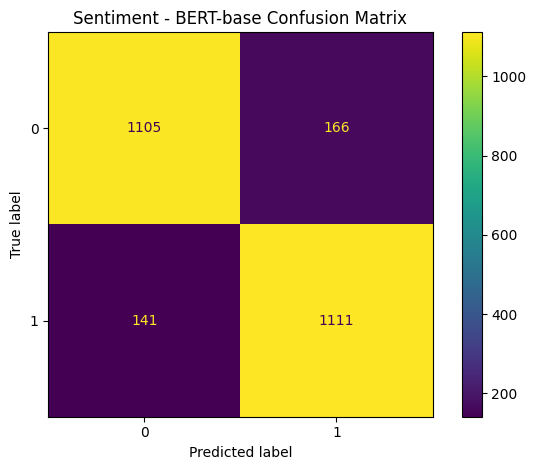

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, bert_pred)

plt.title("Sentiment - BERT-base Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/bert_sentiment_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
bert_results = [
    {
        "task": "Sentiment",
        "model": "BERT-base",
        "accuracy": bert_accuracy,
        "macro_f1": bert_f1,
        "macro_precision": bert_precision,
        "macro_recall": bert_recall
    }
]

bert_results_df = pd.DataFrame(bert_results)

bert_results_df.to_csv("../outputs/tables/bert_sentiment_results.csv", index=False)

bert_results_df

,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sentiment,BERT-base,0.878319,0.878319,0.878423,0.878387


In [ ]:
prediction_df = test_df.copy()
prediction_df["bert_prediction"] = bert_pred

prediction_df.to_csv("../outputs/predictions/bert_sentiment_predictions.csv", index=False)

print("Saved BERT sentiment predictions.")

Saved BERT sentiment predictions.


In [ ]:
wrong_bert = prediction_df[prediction_df["label"] != prediction_df["bert_prediction"]]

print("Number of wrong BERT predictions:", len(wrong_bert))

wrong_bert[["text", "label", "bert_prediction", "variety", "source"]].head(10)

Number of wrong BERT predictions: 307


,text,label,bert_prediction,variety,source
10083,I just returned from running a restaurant in J...,0,1,en-AU,Google
10084,We got pizzas delivered last week and were imp...,0,1,en-AU,Google
10112,Highly recommended and yet the most bland eggs...,0,1,en-AU,Google
10139,"Searched via Google maps, and walked up from t...",0,1,en-AU,Google
10158,very nice place except some lowlife ruined the...,0,1,en-AU,Google
10190,A fairly ordinary cafe and eggs well presented...,0,1,en-AU,Google
10191,"Ordered last night, got a mixed kebab, the pic...",1,0,en-AU,Google
10203,Despite the fact that my pizza order was proce...,1,0,en-AU,Google
10218,First time going here and this is what we got ...,0,1,en-AU,Google
10228,"Over season the chips, cook the chicken to wit...",0,1,en-AU,Google


In [ ]:
model_path = "../outputs/models/bert_sentiment"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print("Saved model to:", model_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.87it/s]

Saved model to: ../outputs/models/bert_sentiment


In [ ]:
baseline_results = pd.read_csv("../outputs/tables/sentiment_baseline_results.csv")

baseline_results

,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sentiment,Majority Class,0.503765,0.335003,0.251883,0.500000
1,Sentiment,TF-IDF + Logistic Regression,0.829964,0.829424,0.833245,0.829588
2,Sentiment,TF-IDF + Linear SVM,0.820848,0.820743,0.821230,0.820713


In [ ]:
all_sentiment_results = pd.concat([baseline_results, bert_results_df], ignore_index=True)

all_sentiment_results

,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sentiment,Majority Class,0.503765,0.335003,0.251883,0.500000
1,Sentiment,TF-IDF + Logistic Regression,0.829964,0.829424,0.833245,0.829588
2,Sentiment,TF-IDF + Linear SVM,0.820848,0.820743,0.821230,0.820713
3,Sentiment,BERT-base,0.878319,0.878319,0.878423,0.878387


In [ ]:
all_sentiment_results.to_csv("../outputs/tables/sentiment_all_results.csv", index=False)

print("Saved sentiment_all_results.csv")

Saved sentiment_all_results.csv


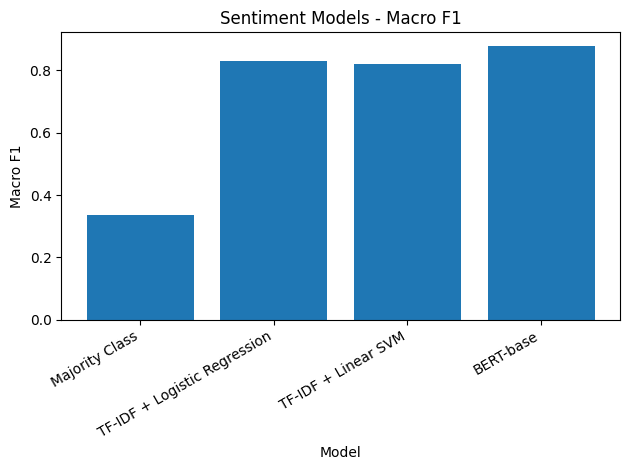

In [ ]:
plt.bar(all_sentiment_results["model"], all_sentiment_results["macro_f1"])

plt.title("Sentiment Models - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_all_models_macro_f1.png", dpi=300)
plt.show()

In [ ]:
print("Sentiment Final Summary")
print("=======================")

display(all_sentiment_results)

best_row = all_sentiment_results.sort_values("macro_f1", ascending=False).iloc[0]

print("\nBest model:")
print(best_row["model"])

print("\nBest Macro-F1:")
print(best_row["macro_f1"])

Sentiment Final Summary


,task,model,accuracy,macro_f1,macro_precision,macro_recall
0,Sentiment,Majority Class,0.503765,0.335003,0.251883,0.500000
1,Sentiment,TF-IDF + Logistic Regression,0.829964,0.829424,0.833245,0.829588
2,Sentiment,TF-IDF + Linear SVM,0.820848,0.820743,0.821230,0.820713
3,Sentiment,BERT-base,0.878319,0.878319,0.878423,0.878387



Best model:
BERT-base

Best Macro-F1:
0.8783187727957599
